# 04 — Optimización de Hiperparámetros

**Técnicas:** GridSearchCV y RandomizedSearchCV  
**Modelos optimizados:** RandomForest, GradientBoosting, LogisticRegression (clasificación) + RandomForest, Ridge (regresión)

---

In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, accuracy_score, r2_score,
                             mean_absolute_error, mean_squared_error)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

print('✅ Librerías importadas')

✅ Librerías importadas


## 1. Carga y Split de Datos

In [6]:
df = pd.read_csv('../data/04_feature/dataset_ml_preparado.csv', encoding='latin-1')

EXCLUDE = ['id_empleado', 'nombre', 'rut', 'departamento', 'cargo',
           'fecha_ingreso', 'salario', 'tipo_contrato', 'jornada',
           'alto_desempeno', 'avg_desempeno', 'score_global']

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]

X = df[feature_cols].copy()
y_clf = df['alto_desempeno'].astype(int)
y_reg = df['avg_desempeno'].copy()

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Train: 204  |  Test: 51
Features (12): ['avg_tecnicas', 'avg_blandas', 'total_dias_ausencia', 'total_horas_capacitacion', 'antiguedad_anos', 'total_dias_ausencia_norm', 'total_horas_capacitacion_norm', 'antiguedad_anos_norm', 'departamento_encoded', 'cargo_encoded', 'tipo_contrato_encoded', 'jornada_encoded']


## 2. GridSearchCV — Clasificación

> Búsqueda exhaustiva sobre una grilla de hiperparámetros definida.

In [7]:
# --- GridSearchCV: LogisticRegression ---
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_lr = {
    'clf__C':       [0.01, 0.1, 1, 10, 100],
    'clf__solver':  ['lbfgs', 'liblinear'],
    'clf__penalty': ['l2'],
}

t0 = time.time()
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5,
                       scoring='f1', n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_clf_train)
print(f'✅ GridSearchCV LogisticRegression — {time.time()-t0:.1f}s')
print(f'   Mejores params: {grid_lr.best_params_}')
print(f'   Mejor CV F1:    {grid_lr.best_score_:.4f}')
print(f'   Test F1:        {f1_score(y_clf_test, grid_lr.predict(X_test)):.4f}')

✅ GridSearchCV LogisticRegression — 3.3s
   Mejores params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
   Mejor CV F1:    0.7749
   Test F1:        0.7059


In [8]:
# --- GridSearchCV: RandomForest Clasificación ---
pipe_rf_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth':    [None, 5, 10],
    'clf__min_samples_split': [2, 5],
}

t0 = time.time()
grid_rf = GridSearchCV(pipe_rf_clf, param_grid_rf, cv=5,
                       scoring='f1', n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_clf_train)
print(f'✅ GridSearchCV RandomForest — {time.time()-t0:.1f}s')
print(f'   Mejores params: {grid_rf.best_params_}')
print(f'   Mejor CV F1:    {grid_rf.best_score_:.4f}')
print(f'   Test F1:        {f1_score(y_clf_test, grid_rf.predict(X_test)):.4f}')

✅ GridSearchCV RandomForest — 2.5s
   Mejores params: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
   Mejor CV F1:    0.7498
   Test F1:        0.7925


## 3. RandomizedSearchCV — Clasificación

> Búsqueda aleatoria sobre distribuciones de hiperparámetros — más eficiente para espacios grandes.

In [11]:
from scipy.stats import randint, uniform

# --- RandomizedSearchCV: GradientBoosting Clasificación ---
pipe_gb_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(random_state=42))
])

param_dist_gb = {
    'clf__n_estimators':  randint(50, 300),
    'clf__learning_rate': uniform(0.01, 0.3),
    'clf__max_depth':     randint(2, 8),
    'clf__subsample':     uniform(0.6, 0.4),
}

t0 = time.time()
rand_gb = RandomizedSearchCV(pipe_gb_clf, param_dist_gb, n_iter=30,
                              cv=5, scoring='f1', random_state=42,
                              n_jobs=-1, verbose=0)
rand_gb.fit(X_train, y_clf_train)
print(f'✅ RandomizedSearchCV GradientBoosting — {time.time()-t0:.1f}s')
print(f'   Mejores params: {rand_gb.best_params_}')
print(f'   Mejor CV F1:    {rand_gb.best_score_:.4f}')
print(f'   Test F1:        {f1_score(y_clf_test, rand_gb.predict(X_test)):.4f}')

✅ RandomizedSearchCV GradientBoosting — 4.7s
   Mejores params: {'clf__learning_rate': np.float64(0.032365193103931246), 'clf__max_depth': 2, 'clf__n_estimators': 137, 'clf__subsample': np.float64(0.7579526072702278)}
   Mejor CV F1:    0.7628
   Test F1:        0.8077


## 4. Comparación: Antes vs Después de Optimización — Clasificación

=== COMPARACIÓN CLASIFICACIÓN ===
            Modelo  F1_Baseline  F1_Optimizado  Mejora
LogisticRegression       0.7547         0.7059 -0.0488
      RandomForest       0.7925         0.7925  0.0000
  GradientBoosting       0.7719         0.8077  0.0358


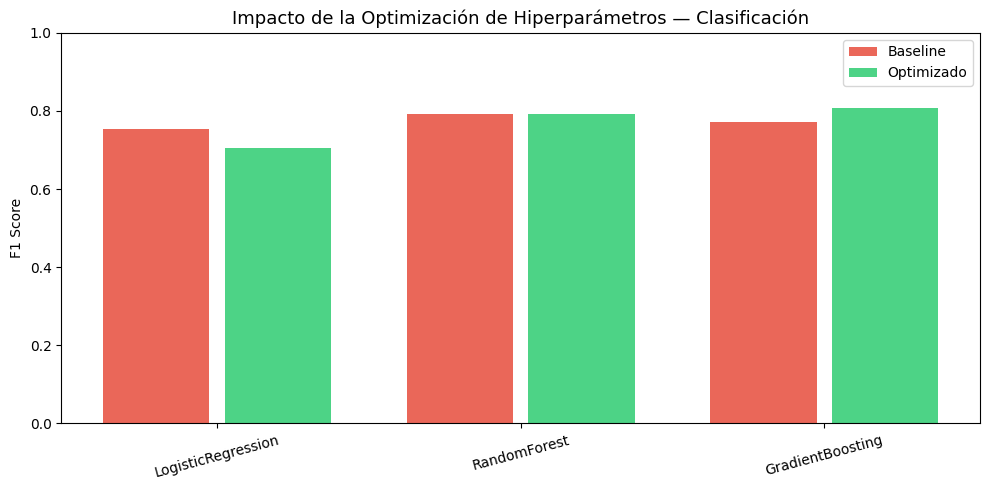

In [12]:
# Baseline (sin optimizar)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

baseline_results = []
for name, model in [
    ('LogisticRegression', LogisticRegression(random_state=42, max_iter=1000)),
    ('RandomForest',       RandomForestClassifier(random_state=42)),
    ('GradientBoosting',   GradientBoostingClassifier(random_state=42)),
]:
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    pipe.fit(X_train, y_clf_train)
    baseline_results.append({
        'Modelo': name,
        'F1_Baseline': round(f1_score(y_clf_test, pipe.predict(X_test)), 4)
    })

optimized_results = [
    {'Modelo': 'LogisticRegression', 'F1_Optimizado': round(f1_score(y_clf_test, grid_lr.predict(X_test)), 4)},
    {'Modelo': 'RandomForest',       'F1_Optimizado': round(f1_score(y_clf_test, grid_rf.predict(X_test)), 4)},
    {'Modelo': 'GradientBoosting',   'F1_Optimizado': round(f1_score(y_clf_test, rand_gb.predict(X_test)), 4)},
]

df_base = pd.DataFrame(baseline_results)
df_opt  = pd.DataFrame(optimized_results)
df_comp_clf = df_base.merge(df_opt, on='Modelo')
df_comp_clf['Mejora'] = (df_comp_clf['F1_Optimizado'] - df_comp_clf['F1_Baseline']).round(4)

print('=== COMPARACIÓN CLASIFICACIÓN ===')
print(df_comp_clf.to_string(index=False))
df_comp_clf.to_csv('../results/metrics/optimizacion_clasificacion.csv', index=False)

x = np.arange(len(df_comp_clf))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, df_comp_clf['F1_Baseline'],  0.35, label='Baseline',   color='#e74c3c', alpha=0.85)
ax.bar(x + 0.2, df_comp_clf['F1_Optimizado'], 0.35, label='Optimizado', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_comp_clf['Modelo'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_title('Impacto de la Optimización de Hiperparámetros — Clasificación', fontsize=13)
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('../results/plots/04_optimizacion_clasificacion.png', bbox_inches='tight', dpi=120)
plt.show()

## 5. GridSearchCV — Regresión

In [13]:
# --- GridSearchCV: Ridge Regresión ---
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Ridge(random_state=42))
])

param_grid_ridge = {
    'reg__alpha': [0.01, 0.1, 1, 10, 100, 1000],
}

t0 = time.time()
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5,
                          scoring='r2', n_jobs=-1, verbose=0)
grid_ridge.fit(X_train, y_reg_train)
print(f'✅ GridSearchCV Ridge — {time.time()-t0:.1f}s')
print(f'   Mejores params: {grid_ridge.best_params_}')
print(f'   Mejor CV R2:    {grid_ridge.best_score_:.4f}')
print(f'   Test R2:        {r2_score(y_reg_test, grid_ridge.predict(X_test)):.4f}')

✅ GridSearchCV Ridge — 0.1s
   Mejores params: {'reg__alpha': 100}
   Mejor CV R2:    -0.0156
   Test R2:        -0.0934


## 6. RandomizedSearchCV — Regresión

In [14]:
# --- RandomizedSearchCV: RandomForest Regresión ---
pipe_rf_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', RandomForestRegressor(random_state=42))
])

param_dist_rf_reg = {
    'reg__n_estimators': randint(50, 300),
    'reg__max_depth':    randint(3, 20),
    'reg__min_samples_split': randint(2, 10),
    'reg__max_features': ['sqrt', 'log2', None],
}

t0 = time.time()
rand_rf_reg = RandomizedSearchCV(pipe_rf_reg, param_dist_rf_reg, n_iter=30,
                                  cv=5, scoring='r2', random_state=42,
                                  n_jobs=-1, verbose=0)
rand_rf_reg.fit(X_train, y_reg_train)
print(f'✅ RandomizedSearchCV RandomForest Regresión — {time.time()-t0:.1f}s')
print(f'   Mejores params: {rand_rf_reg.best_params_}')
print(f'   Mejor CV R2:    {rand_rf_reg.best_score_:.4f}')
print(f'   Test R2:        {r2_score(y_reg_test, rand_rf_reg.predict(X_test)):.4f}')

✅ RandomizedSearchCV RandomForest Regresión — 4.8s
   Mejores params: {'reg__max_depth': 3, 'reg__max_features': 'log2', 'reg__min_samples_split': 7, 'reg__n_estimators': 285}
   Mejor CV R2:    -0.0329
   Test R2:        -0.0810


## 7. Comparación: Antes vs Después — Regresión

=== COMPARACIÓN REGRESIÓN ===
      Modelo  R2_Baseline  R2_Optimizado  Mejora
       Ridge      -0.1548        -0.0934  0.0614
RandomForest      -0.1470        -0.0810  0.0660


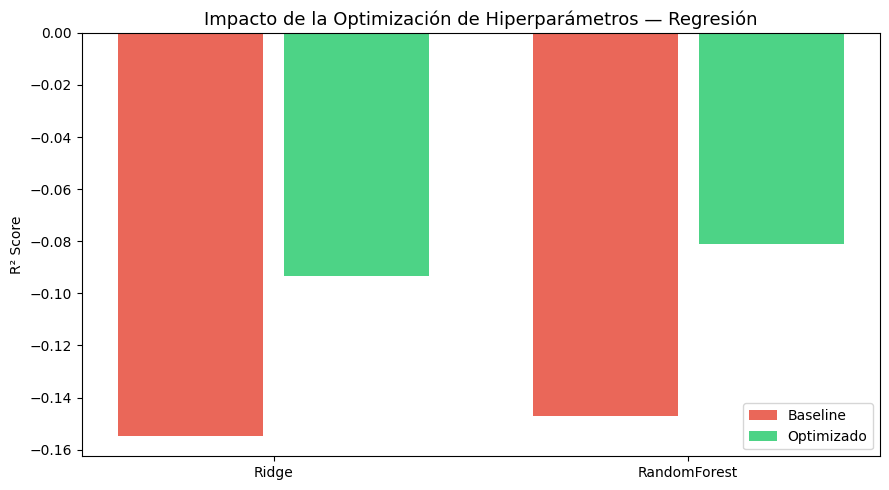

In [15]:
from sklearn.linear_model import LinearRegression

baseline_reg = []
for name, model in [
    ('Ridge',        Ridge(random_state=42)),
    ('RandomForest', RandomForestRegressor(random_state=42)),
]:
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', model)])
    pipe.fit(X_train, y_reg_train)
    baseline_reg.append({
        'Modelo': name,
        'R2_Baseline': round(r2_score(y_reg_test, pipe.predict(X_test)), 4)
    })

optimized_reg = [
    {'Modelo': 'Ridge',        'R2_Optimizado': round(r2_score(y_reg_test, grid_ridge.predict(X_test)), 4)},
    {'Modelo': 'RandomForest', 'R2_Optimizado': round(r2_score(y_reg_test, rand_rf_reg.predict(X_test)), 4)},
]

df_comp_reg = pd.DataFrame(baseline_reg).merge(pd.DataFrame(optimized_reg), on='Modelo')
df_comp_reg['Mejora'] = (df_comp_reg['R2_Optimizado'] - df_comp_reg['R2_Baseline']).round(4)

print('=== COMPARACIÓN REGRESIÓN ===')
print(df_comp_reg.to_string(index=False))
df_comp_reg.to_csv('../results/metrics/optimizacion_regresion.csv', index=False)

x = np.arange(len(df_comp_reg))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, df_comp_reg['R2_Baseline'],  0.35, label='Baseline',   color='#e74c3c', alpha=0.85)
ax.bar(x + 0.2, df_comp_reg['R2_Optimizado'], 0.35, label='Optimizado', color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(df_comp_reg['Modelo'])
ax.set_ylabel('R² Score')
ax.set_title('Impacto de la Optimización de Hiperparámetros — Regresión', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../results/plots/04_optimizacion_regresion.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. Curvas de Validación — GridSearchCV Results

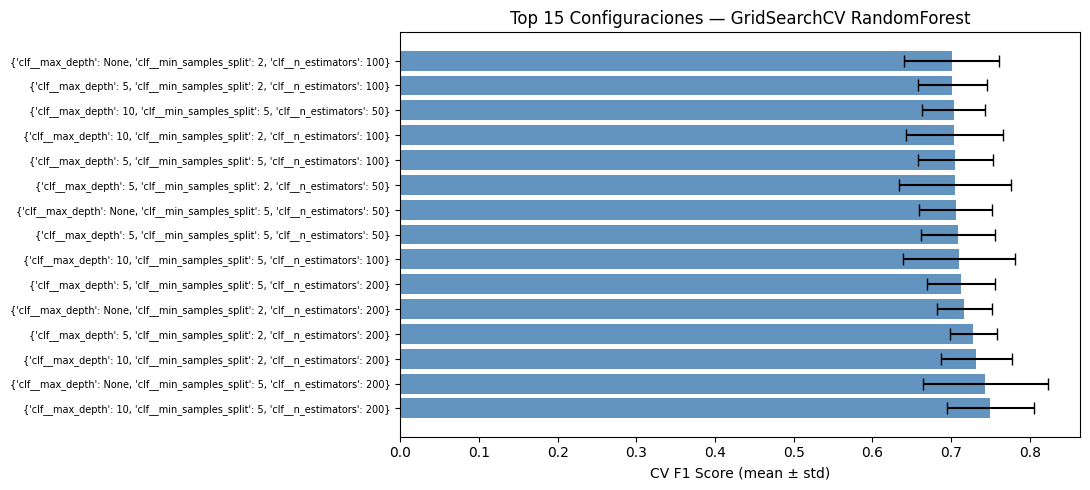

In [16]:
# Visualizar resultados del GridSearch (CV score por configuración)
cv_results = pd.DataFrame(grid_rf.cv_results_)
cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False).head(15)

plt.figure(figsize=(11, 5))
plt.barh(range(len(cv_results_sorted)),
         cv_results_sorted['mean_test_score'],
         xerr=cv_results_sorted['std_test_score'],
         color='steelblue', alpha=0.85, capsize=4)
plt.yticks(range(len(cv_results_sorted)),
           [str(p) for p in cv_results_sorted['params']], fontsize=7)
plt.xlabel('CV F1 Score (mean ± std)')
plt.title('Top 15 Configuraciones — GridSearchCV RandomForest', fontsize=12)
plt.tight_layout()
plt.savefig('../results/plots/04_grid_results.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 9. Resumen de Optimización

| Método | Modelo | Tarea | Params Explorados |
|--------|--------|-------|-------------------|
| GridSearchCV | LogisticRegression | Clasificación | C, solver |
| GridSearchCV | RandomForest | Clasificación | n_estimators, max_depth |
| RandomizedSearchCV | GradientBoosting | Clasificación | learning_rate, n_estimators, max_depth |
| GridSearchCV | Ridge | Regresión | alpha |
| RandomizedSearchCV | RandomForest | Regresión | n_estimators, max_depth, features |

**Conclusión:** RandomizedSearchCV es más eficiente para espacios de búsqueda grandes, mientras que GridSearchCV garantiza encontrar el óptimo dentro de la grilla definida.